# Validating the (re)simulation — the proper estimators

We compare a candidate density field (a resimulation) to a reference (the full simulation) with the **standard cosmological field-level diagnostics** (`oneuniverse.simulation.validation.validate_field`):

| estimator | definition | measures | perfect |
|---|---|---|---|
| **r(k)** | P_ab/√(P_aa P_bb) | *phase* agreement (structure in the right place) | 1 |
| **T(k)** | P_ab/P_bb | *amplitude* recovery (δ_a≈T·δ_b) | 1 |
| **P_aa/P_bb** | power ratio | total power match | 1 |
| **S(k)=1−r²** | stochasticity | variance the reference can't predict | 0 |
| **k_half** | r(k)=0.5 | the scale agreement breaks down | →∞ |
| **PDF** | 1-point histogram | non-Gaussian / amplitude beyond 2-pt | match |

Decomposition: P_aa = T²·P_bb + P_noise, with P_noise/P_aa = 1−r².

In [1]:
%matplotlib inline
import numpy as np, matplotlib.pyplot as plt
from oneuniverse.simulation.cosmology import CosmologySpec
from oneuniverse.simulation.linear.gaussian_field import generate_density_field
from oneuniverse.simulation.validation import validate_field
from oneuniverse.simulation.resim.coupling import (run_full_reference,
    run_coupled, full_target_slice)
from oneuniverse.simulation.resim.treepm import run_coupled_treepm
from oneuniverse.simulation.pm.run import run_pm, zeldovich_pm_ic_from_field
from oneuniverse.simulation.pm.deposit import deposit_cic
C = CosmologySpec(omega_m=0.31, omega_b=0.048, h=0.67, n_s=0.96, sigma8=0.81, t_cmb=2.7255)
BOX, N, TLO, TS, NS = 256.0, 64, 96.0, 64.0, 18
ic = generate_density_field(C, box_size=BOX, n_grid=N, z=0.0, seed=2)
full = run_full_reference(C, box=BOX, n_grid=N, z_start=9.0, z_end=0.0, seed=2, n_steps=NS)
ref = full_target_slice(full, box=BOX, n_grid=N, target_lo=TLO, target_side=TS)
def uncoupled(buf):
    return run_coupled(C, box=BOX, n_grid=N, target_lo=TLO, target_side=TS,
        buffer=buf, z_start=9.0, z_end=0.0, seed=2, n_steps=NS)['inner']
def treepm(buf):
    return run_coupled_treepm(C, ic, box=BOX, n_grid=N, target_lo=TLO,
        target_side=TS, buffer=buf, z_start=9.0, z_end=0.0, n_steps=NS)['inner']
print('reference + resim functions ready')

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


reference + resim functions ready


## 1. Visual: reference vs the two resimulation methods (buffer 16)
Uncoupled buffered run vs the TreePM-split (full-box linear long-range force + tile short-range).

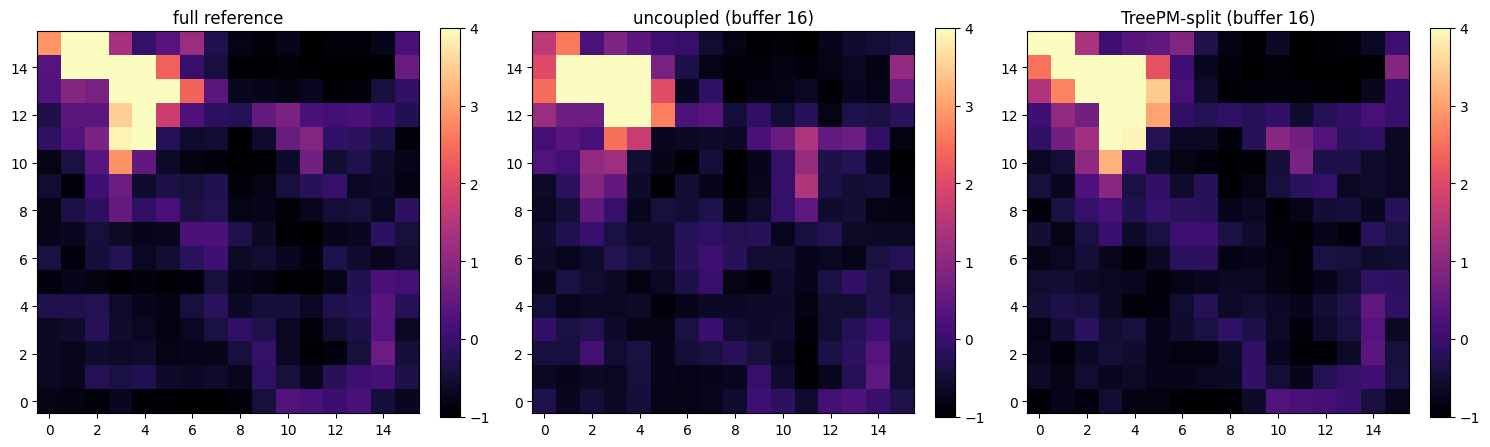

In [2]:
b = 16.0
u, t = uncoupled(b), treepm(b)
sl = ref.shape[2]//2
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
for a, f, ttl in ((ax[0], ref, 'full reference'),
                  (ax[1], u, f'uncoupled (buffer {b:.0f})'),
                  (ax[2], t, f'TreePM-split (buffer {b:.0f})')):
    im = a.imshow(f[:,:,sl].T, origin='lower', cmap='magma', vmin=-1, vmax=4)
    a.set_title(ttl); plt.colorbar(im, ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

## 2. The two-point estimators (uncoupled vs TreePM at buffer 16)
TreePM should be closer to perfect on **all four**: r→1, T→1, power-ratio→1, stochasticity→0.

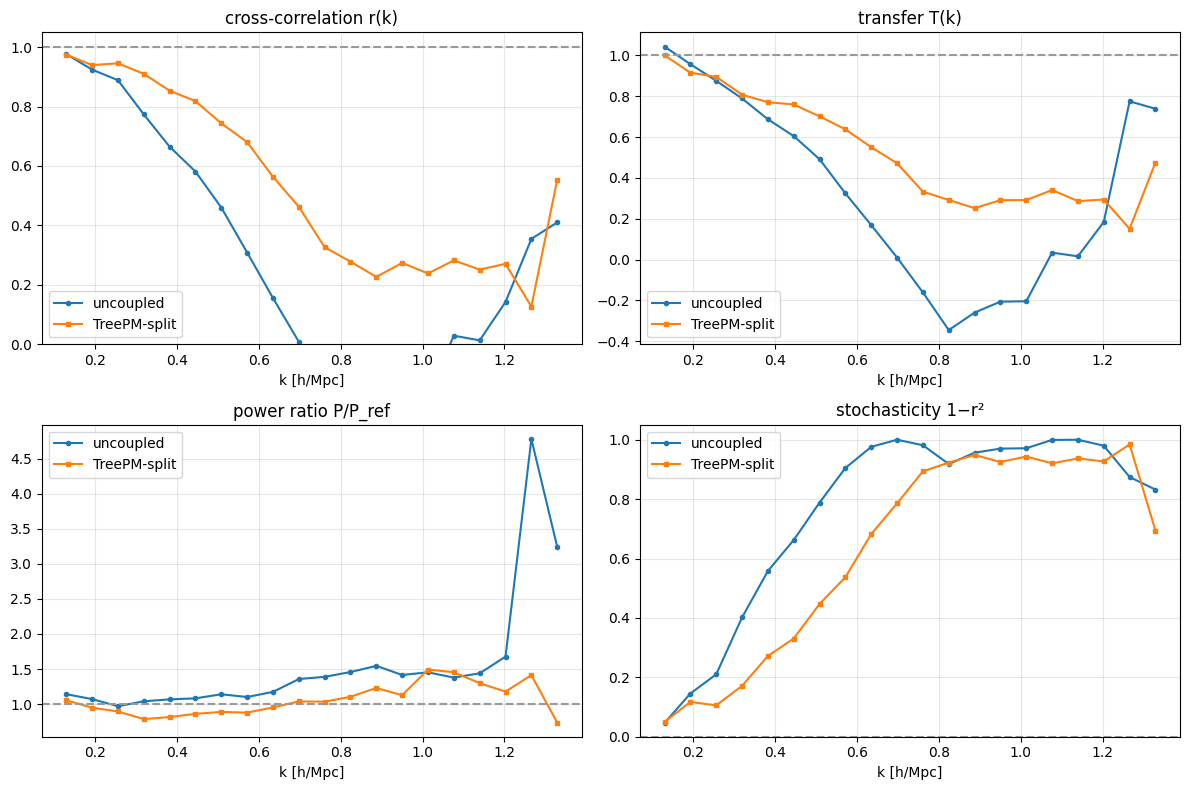

k_half:  uncoupled=0.51   TreePM=0.70  h/Mpc (higher = better)


In [3]:
vu = validate_field(u, ref, box=TS); vt = validate_field(t, ref, box=TS)
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for a, key, ttl, hl in ((ax[0,0],'r','cross-correlation r(k)',1),
                        (ax[0,1],'transfer','transfer T(k)',1),
                        (ax[1,0],'power_ratio','power ratio P/P_ref',1),
                        (ax[1,1],'stochasticity','stochasticity 1−r²',0)):
    a.plot(vu.k, getattr(vu,key), 'o-', ms=3, label='uncoupled')
    a.plot(vt.k, getattr(vt,key), 's-', ms=3, label='TreePM-split')
    a.axhline(hl, color='.6', ls='--'); a.set_xlabel('k [h/Mpc]')
    a.set_title(ttl); a.legend(); a.grid(alpha=.3)
ax[0,0].set_ylim(0,1.05); ax[1,1].set_ylim(0,1.05)
plt.tight_layout(); plt.show()
print(f'k_half:  uncoupled={vu.k_half:.2f}   TreePM={vt.k_half:.2f}  h/Mpc (higher = better)')

## 3. Buffer convergence — TreePM reaches the same agreement at a smaller buffer
Headline of the resimulation proof of concept: the TreePM curve sits above the uncoupled one everywhere, so a target accuracy is reached at a smaller (cheaper) buffer.

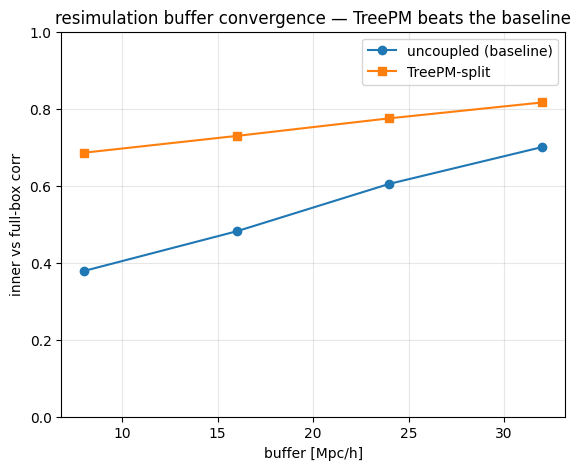

uncoupled: [0.379 0.482 0.605 0.7  ]
TreePM   : [0.686 0.729 0.775 0.816]
-> TreePM@buffer8 (0.69) ~ uncoupled@buffer32 (0.70): same accuracy, ~4x smaller buffer


In [4]:
buffers = [8.0, 16.0, 24.0, 32.0]
cu = [np.corrcoef(uncoupled(b).ravel(), ref.ravel())[0,1] for b in buffers]
ct = [np.corrcoef(treepm(b).ravel(), ref.ravel())[0,1] for b in buffers]
plt.figure(figsize=(6.5,5))
plt.plot(buffers, cu, 'o-', label='uncoupled (baseline)')
plt.plot(buffers, ct, 's-', label='TreePM-split')
plt.xlabel('buffer [Mpc/h]'); plt.ylabel('inner vs full-box corr'); plt.ylim(0,1)
plt.title('resimulation buffer convergence — TreePM beats the baseline'); plt.legend(); plt.grid(alpha=.3); plt.show()
print('uncoupled:', np.round(cu,3)); print('TreePM   :', np.round(ct,3))
print(f'-> TreePM@buffer{buffers[0]:.0f} ({ct[0]:.2f}) ~ uncoupled@buffer{buffers[-1]:.0f} ({cu[-1]:.2f}): same accuracy, ~{buffers[-1]/buffers[0]:.0f}x smaller buffer')

## 4. 1-point PDF — beyond two-point statistics
Does the resimulated field have the right *density distribution* (non-Gaussian tail)? Compares the PDF to the reference.

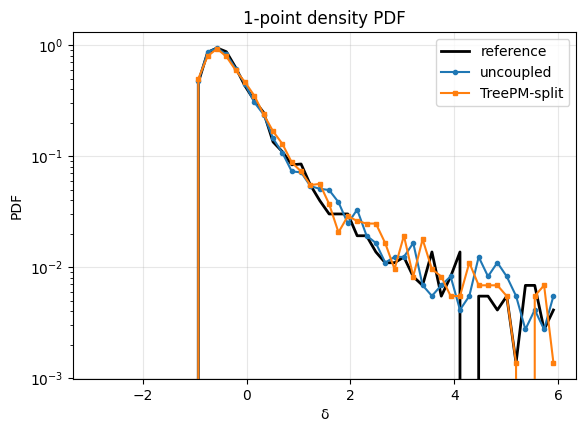

variance:  reference=6.04  uncoupled=6.99  TreePM=5.65


In [5]:
ctr = 0.5*(vt.pdf_edges[:-1]+vt.pdf_edges[1:])
plt.figure(figsize=(6.5,4.5))
plt.semilogy(ctr, vt.pdf_b, 'k-', lw=2, label='reference')
plt.semilogy(ctr, vu.pdf_a, 'o-', ms=3, label='uncoupled')
plt.semilogy(ctr, vt.pdf_a, 's-', ms=3, label='TreePM-split')
plt.xlabel('δ'); plt.ylabel('PDF'); plt.title('1-point density PDF'); plt.legend(); plt.grid(alpha=.3); plt.show()
print(f'variance:  reference={vt.var_b:.2f}  uncoupled={vu.var_a:.2f}  TreePM={vt.var_a:.2f}')

## 5. The PM itself vs linear theory (sanity)
Before trusting the resim, the full PM must reproduce **linear growth** on large scales. r→1 and T→1 at low k; the high-k transfer deficit is the PM mesh force resolution (expected).

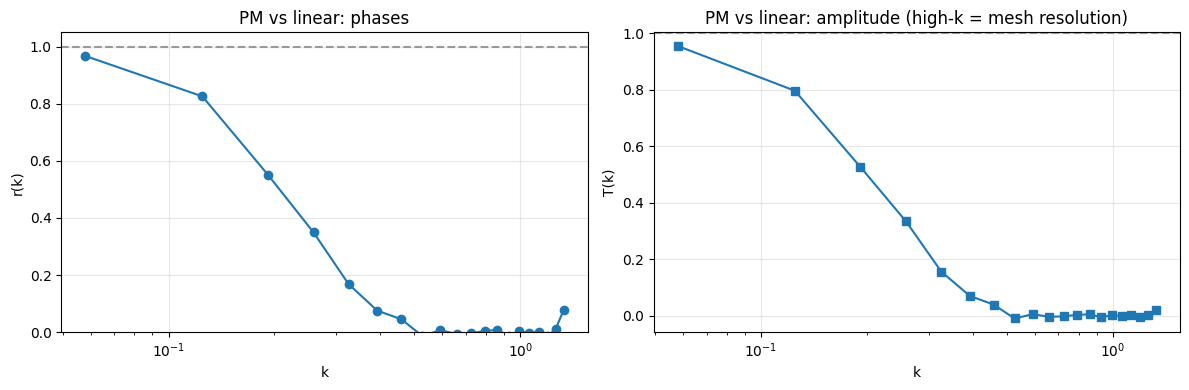

PM vs linear at low k:  r=0.967  T=0.956


In [6]:
pos, p0 = zeldovich_pm_ic_from_field(C, ic, box=BOX, n_grid=N, z_start=9.0)
x,_ = run_pm(pos, p0, box=BOX, n_grid=N, cosmo=C, a_start=0.1, a_end=1.0, n_steps=25)
rho = deposit_cic(x, N, BOX); d_pm = rho/rho.mean()-1
vp = validate_field(d_pm, ic, box=BOX)   # PM(z=0) vs linear(z=0)
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].semilogx(vp.k, vp.r, 'o-'); ax[0].axhline(1, color='.6', ls='--')
ax[0].set_xlabel('k'); ax[0].set_ylabel('r(k)'); ax[0].set_title('PM vs linear: phases'); ax[0].set_ylim(0,1.05); ax[0].grid(alpha=.3)
ax[1].semilogx(vp.k, vp.transfer, 's-'); ax[1].axhline(1, color='.6', ls='--')
ax[1].set_xlabel('k'); ax[1].set_ylabel('T(k)'); ax[1].set_title('PM vs linear: amplitude (high-k = mesh resolution)'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f'PM vs linear at low k:  r={np.nanmedian(vp.r[vp.k<0.06]):.3f}  T={np.nanmedian(vp.transfer[vp.k<0.06]):.3f}')

## 6. Summary + what is still imperfect

**Validated:** TreePM-split resimulation is closer to the full sim on *every* estimator (r, T, power, stochasticity) and reaches a given accuracy at a ~4× smaller buffer. The PM reproduces linear growth at large scales.

**Still imperfect (honest):**
- **small-scale stochasticity** stays >0 (the inner small scales are a new non-linear realisation, not the exact reference) — fundamental to any resim, and capped by the toy PM's mesh force resolution;
- the **high-k transfer deficit** (PM under-resolves small scales; a real run uses a finer mesh / PM+tree);
- super-parent-box tides are dropped (irreducible).

In [7]:
import numpy as np
print('estimator summary (buffer 16):')
for name, v in (('uncoupled', vu), ('TreePM', vt)):
    band = (v.k>0.1)&(v.k<0.3)
    print(f'  {name:9s}  k_half={v.k_half:.2f}  r@midk={np.nanmedian(v.r[band]):.3f}  '
          f'stoch@midk={np.nanmedian(v.stochasticity[band]):.3f}')

estimator summary (buffer 16):
  uncoupled  k_half=0.51  r@midk=0.924  stoch@midk=0.145
  TreePM     k_half=0.70  r@midk=0.946  stoch@midk=0.106
